# Class 15 non-inertial-frame experiment

This notebook loads the trajectory exported from Tracker and plots the measured path on a circular coordinate grid. Position units are centimeters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("Class15_experiment.txt")
data = np.loadtxt(data_path, skiprows=2)

t_s = data[:, 0]
x_cm = data[:, 1]
y_cm = data[:, 2]

print(f"Loaded {len(t_s)} points from {data_path}")
print(f"Time interval: {t_s[0]:.3f} to {t_s[-1]:.3f} s")

Loaded 17 points from Class15_experiment.txt
Time interval: 0.000 to 0.704 s


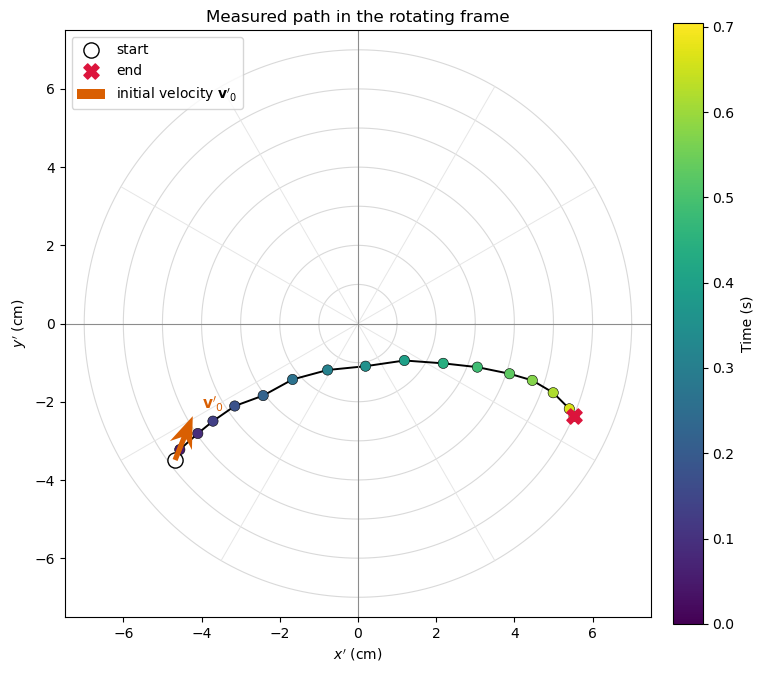

In [2]:
# Use the same constrained six-point quadratic fit as below for the velocity arrow.
n_fit_arrow = 6
t_arrow_fit = t_s[:n_fit_arrow]
arrow_design = np.column_stack((t_arrow_fit[1:], 0.5 * t_arrow_fit[1:]**2))
vx0_arrow, _ = np.linalg.lstsq(
    arrow_design, x_cm[1:n_fit_arrow] - x_cm[0], rcond=None
)[0]
vy0_arrow, _ = np.linalg.lstsq(
    arrow_design, y_cm[1:n_fit_arrow] - y_cm[0], rcond=None
)[0]

radius_cm = np.hypot(x_cm, y_cm)
plot_radius_cm = np.ceil(radius_cm.max())

fig, ax = plt.subplots(figsize=(8, 8))

# Circular grid rings
theta = np.linspace(0, 2 * np.pi, 500)
for radius in np.arange(1, plot_radius_cm + 1):
    ax.plot(
        radius * np.cos(theta),
        radius * np.sin(theta),
        color="0.85",
        linewidth=0.8,
        zorder=0,
    )

# Radial guides every 30 degrees
for angle in np.deg2rad(np.arange(0, 360, 30)):
    ax.plot(
        [0, plot_radius_cm * np.cos(angle)],
        [0, plot_radius_cm * np.sin(angle)],
        color="0.90",
        linewidth=0.7,
        zorder=0,
    )

points = ax.scatter(
    x_cm,
    y_cm,
    c=t_s,
    cmap="viridis",
    s=55,
    edgecolor="black",
    linewidth=0.4,
    zorder=3,
)
ax.plot(x_cm, y_cm, color="black", linewidth=1.4, zorder=2)
ax.scatter(x_cm[0], y_cm[0], marker="o", s=120, facecolor="white", edgecolor="black", label="start", zorder=4)
ax.scatter(x_cm[-1], y_cm[-1], marker="X", s=120, color="crimson", label="end", zorder=4)

# Initial-velocity vector. Multiplying by 0.15 s gives a readable arrow length in cm.
arrow_dt_s = 0.15
ax.quiver(
    x_cm[0],
    y_cm[0],
    vx0_arrow * arrow_dt_s,
    vy0_arrow * arrow_dt_s,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="#d95f02",
    width=0.009,
    headwidth=4.5,
    headlength=6,
    zorder=5,
    label=r"initial velocity $\mathbf{v}'_0$",
)
ax.annotate(
    r"$\mathbf{v}'_0$",
    (x_cm[0] + vx0_arrow * arrow_dt_s, y_cm[0] + vy0_arrow * arrow_dt_s),
    xytext=(7, 5),
    textcoords="offset points",
    color="#d95f02",
    fontsize=11,
    fontweight="bold",
)

limit = plot_radius_cm + 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color="0.55", linewidth=0.8)
ax.axvline(0, color="0.55", linewidth=0.8)
ax.set_xlabel("$x'$ (cm)")
ax.set_ylabel("$y'$ (cm)")
ax.set_title("Measured path in the rotating frame")
ax.legend(loc="upper left")
colorbar = fig.colorbar(points, ax=ax, shrink=0.78, pad=0.03)
colorbar.set_label("Time (s)")
fig.tight_layout()
plt.show()

## Estimate the initial conditions

Take the first measured point as the initial position. To reduce frame-to-frame noise in the velocity, fit a local quadratic over the first six measurements (through $t=0.220\,\mathrm{s}$), while constraining the fit to pass through the measured initial position:

$$q(t)-q(0) = v_{q,0}t + \tfrac12 a_{q,0}t^2, \qquad q=x',y'.$$

The coefficient of $t$ estimates the initial velocity. The nearby-window comparison below gives a simple indication of sensitivity to the chosen fitting interval.

In [3]:
n_fit = 6  # first 6 points: t = 0 through 0.220 s
t_fit = t_s[:n_fit]

# Constrained quadratic: q(t) = q0 + v0*t + (1/2)*a0*t**2
design = np.column_stack((t_fit[1:], 0.5 * t_fit[1:]**2))
vx0_cm_s, ax0_cm_s2 = np.linalg.lstsq(
    design, x_cm[1:n_fit] - x_cm[0], rcond=None
)[0]
vy0_cm_s, ay0_cm_s2 = np.linalg.lstsq(
    design, y_cm[1:n_fit] - y_cm[0], rcond=None
)[0]

x0_cm, y0_cm = x_cm[0], y_cm[0]

print("Estimated rotating-frame initial conditions")
print(f"x'(0)  = {x0_cm:7.3f} cm")
print(f"y'(0)  = {y0_cm:7.3f} cm")
print(f"vx'(0) = {vx0_cm_s:7.3f} cm/s")
print(f"vy'(0) = {vy0_cm_s:7.3f} cm/s")
print(f"Local-fit accelerations: ax'(0) = {ax0_cm_s2:.2f} cm/s², "
      f"ay'(0) = {ay0_cm_s2:.2f} cm/s²")

Estimated rotating-frame initial conditions
x'(0)  =  -4.677 cm
y'(0)  =  -3.490 cm
vx'(0) =   3.015 cm/s
vy'(0) =   7.479 cm/s
Local-fit accelerations: ax'(0) = 65.48 cm/s², ay'(0) = 1.25 cm/s²


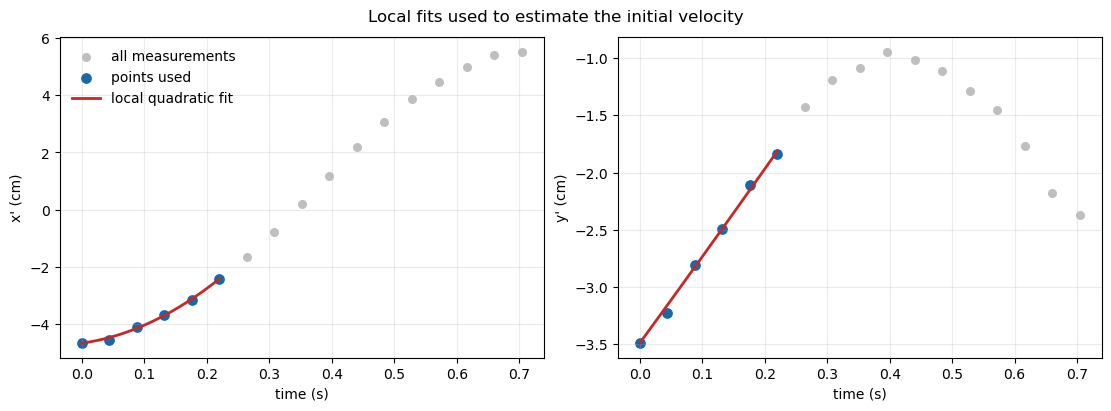

In [4]:
t_smooth = np.linspace(0, t_fit[-1], 200)
x_local = x0_cm + vx0_cm_s * t_smooth + 0.5 * ax0_cm_s2 * t_smooth**2
y_local = y0_cm + vy0_cm_s * t_smooth + 0.5 * ay0_cm_s2 * t_smooth**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, measured, fitted, label in [
    (axes[0], x_cm, x_local, "x'"),
    (axes[1], y_cm, y_local, "y'"),
]:
    ax.scatter(t_s, measured, color="0.75", s=30, label="all measurements")
    ax.scatter(t_fit, measured[:n_fit], color="#1769aa", s=45, label="points used")
    ax.plot(t_smooth, fitted, color="#c62828", linewidth=2, label="local quadratic fit")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(f"{label} (cm)")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False)
fig.suptitle("Local fits used to estimate the initial velocity")
plt.show()

In [5]:
# Sensitivity to using 5, 6, or 7 early-time points
window_results = []
for n_window in (5, 6, 7):
    tw = t_s[:n_window]
    Aw = np.column_stack((tw[1:], 0.5 * tw[1:]**2))
    vx_window = np.linalg.lstsq(Aw, x_cm[1:n_window] - x_cm[0], rcond=None)[0][0]
    vy_window = np.linalg.lstsq(Aw, y_cm[1:n_window] - y_cm[0], rcond=None)[0][0]
    window_results.append((n_window, tw[-1], vx_window, vy_window))

print("points   t_max (s)   vx'(0) (cm/s)   vy'(0) (cm/s)")
for n_window, t_max, vx_window, vy_window in window_results:
    print(f"{n_window:>4d}      {t_max:6.3f}        {vx_window:8.3f}         {vy_window:8.3f}")

velocity_samples = np.array([[row[2], row[3]] for row in window_results])
print("\nWindow sensitivity (sample standard deviation):")
print(f"vx'(0): {velocity_samples[:, 0].std(ddof=1):.3f} cm/s")
print(f"vy'(0): {velocity_samples[:, 1].std(ddof=1):.3f} cm/s")

points   t_max (s)   vx'(0) (cm/s)   vy'(0) (cm/s)
   5       0.176           3.148            6.740
   6       0.220           3.015            7.479
   7       0.264           3.309            7.309

Window sensitivity (sample standard deviation):
vx'(0): 0.147 cm/s
vy'(0): 0.387 cm/s


### Initial-condition estimate to use in the equations of motion

Using the six-point constrained quadratic fit,

$$\boxed{(x'_0,y'_0)=(-4.677,-3.490)\ \mathrm{cm}}$$

$$\boxed{(\dot{x}'_0,\dot{y}'_0)\approx(3.02,7.48)\ \mathrm{cm/s}}.$$

The velocity estimate changes by roughly $0.15\,\mathrm{cm/s}$ in $x'$ and $0.39\,\mathrm{cm/s}$ in $y'$ when the fit window is varied from five to seven points. This is a fitting-window sensitivity, not a complete experimental uncertainty.